# Finalize the icechunk store

Post-fleet cleanup — run once per release (after the initial fleet, and again after any
future water-year append campaign), and only when
[`2_check_tile_status.ipynb`](2_check_tile_status.ipynb) shows every tile complete and nothing
is dispatching. In order: freeze the commit-metadata ledger, tag the release, garbage-collect
the object bloat left behind by fleet commit contention, and sweep the repo-info backups that
icechunk never deletes on its own. For scale: at v10 fleet completion (2026-08-11) the repo
held 2.49 TB / 3.39 M objects, of which only 65.6 GB was live chunk data.

**Deliberately no `expire_snapshots`.** The commit history is the processing ledger —
[`status.py`](../global_snowmelt_runoff_onset/status.py) derives all tile status and the
manuscript's bulk-processing numbers from per-commit metadata — and expiration collapses the
ancestry to tip→root, after which GC deletes every historical commit and its metadata with it.
Steps 5–7 reclaim ~97% of the dead weight without touching history; expiring would add only a
few GB more. If a future cleanup ever does expire, the step-2 parquet becomes the only
surviving record, so never skip it.

In [1]:
import datetime
import json
import pathlib
from concurrent.futures import ThreadPoolExecutor

import icechunk
import pandas as pd
from azure.storage.blob import ContainerClient

from global_snowmelt_runoff_onset.config import Config
from global_snowmelt_runoff_onset import status, store

config = Config('config/global_config_v10.txt')
repo = config.open_output_repo()

container, repo_prefix = config.global_runoff_icechunk_azure_prefix.split('/', 1)
account_url = f'https://{config.azure_storage_account}.blob.core.windows.net'

SAS token is valid until 2026-08-26 19:52 UTC (359.0 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v10
version = v10
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 84.048
bbox_bottom = -63.4074
expected_grid_shape = 204800, 499998
expected_tile_grid = 100, 245
wy_start = 2015
wy_end = 2025
trailing_buffer_days = 120
low_backscatter_threshold = 0.001
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow_v10.geojson
global_runoff_icechunk_azure_prefix = snowmelt/snowmelt_runoff_onset/global_runoff_onset_v10
inner_chunk_dim = 256
snow_phenology_zarr_store_azure_path = snowmelt/modis_sn

## 1. Preconditions

Everything below assumes a finished, quiet store: no remaining work items, and the newest
commit at least an hour old (that's the GC cutoff in step 5). The version floor matters —
GC before icechunk 2.1.0 deletes transaction logs in a way that permanently breaks history
diffs for every client.

In [3]:
from packaging.version import Version

assert Version(icechunk.__version__) >= Version('2.1.0'), \
    f'icechunk {icechunk.__version__} -- GC needs >= 2.1.0'

work = status.get_remaining_work(config, repo=repo)
assert not work, f'{len(work)} tiles still need work -- the fleet is not done'

commits_df = status.get_commit_records(repo)
commits_df['written_at'] = pd.to_datetime(commits_df['written_at'], utc=True)
commits_df['water_year'] = commits_df['water_year'].astype('Int64')

newest = commits_df.written_at.max()
quiet_h = (pd.Timestamp.now(tz='UTC') - newest).total_seconds() / 3600
print(f'{len(commits_df):,} pipeline commits '
      f'({(commits_df.kind == status.KIND_TILE_YEAR).sum():,} tile-year, '
      f'{(commits_df.kind == status.KIND_TILE_COMPOSITE).sum():,} composite)')
print(f'newest: {newest:%Y-%m-%d %H:%M UTC} ({quiet_h:.1f} h ago)')
assert quiet_h > 1, 'newest commit is under an hour old -- is a run still in flight?'

53,736 pipeline commits (49,258 tile-year, 4,478 composite)
newest: 2026-08-11 14:12 UTC (6.7 h ago)


## 2. Freeze the ledger

Lossless export of every pipeline commit's metadata (status, stats, provenance, dropped
scenes) to `results/<version>/commit_ledger.parquet`, which goes in git. The derived CSV
snapshots are `2_check_tile_status.ipynb`'s job — re-run that first if they're stale.

In [4]:
ledger = commits_df.copy()
for column in ('stats', 'provenance'):
    ledger[column] = ledger[column].map(
        lambda d: json.dumps(d) if isinstance(d, dict) else None)
ledger['missing_assets'] = ledger['missing_assets'].map(
    lambda v: json.dumps(list(v)) if isinstance(v, (list, tuple)) else None)

assert ledger.snapshot_id.is_unique

ledger_path = pathlib.Path('results') / config.version / 'commit_ledger.parquet'
ledger_path.parent.mkdir(parents=True, exist_ok=True)
ledger.to_parquet(ledger_path, index=False)
print(f'wrote {len(ledger):,} commits -> {ledger_path} '
      f'({ledger_path.stat().st_size / 1e6:.1f} MB)')

wrote 53,736 commits -> results/v10/commit_ledger.parquet (8.9 MB)


## 3. Tag the release

Tags are GC roots (like branch tips), so the tag both names the released snapshot and pins
its objects. Everything downstream — pyramid generation, the map, evaluation notebooks —
should open the store at this tag, not at `main`. The cell never moves an existing tag; when re-finalizing after appending a water year,
bump the minor (`v10.1`, ...) instead.

In [5]:
tag = f'{config.version}.0'  # bump the minor when re-finalizing after a water-year append
tip = repo.lookup_branch('main')

if tag in repo.list_tags():
    existing = repo.lookup_tag(tag)
    marker = 'the main tip' if existing == tip else f'NOT the main tip ({tip})'
    print(f'tag {tag} already exists at {existing} -- {marker}')
else:
    repo.create_tag(tag, snapshot_id=tip)
    print(f'created tag {tag} -> {tip}')

tag v10.0 already exists at 5GXWVWYG3BG5XMFXNAH0 -- the main tip


## 4. Storage footprint, before

Per-prefix size/object counts straight from a blob listing — the repo is just live `chunks/`,
per-commit `manifests/` + `snapshots/` + `transactions/`, the `repo` info object, and
`overwritten/` (old copies of that info object; step 7). Listing a few million objects takes
~5–10 min; the same helper re-runs in step 8 for the before/after table.

In [6]:
def prefix_sizes() -> pd.DataFrame:
    """Size and object count under each top-level prefix of the repo."""
    client = ContainerClient(account_url, container, credential=config.sas_token)
    tops = [b.name for b in client.walk_blobs(
        name_starts_with=repo_prefix + '/', delimiter='/')]

    def walk(top):
        c = ContainerClient(account_url, container, credential=config.sas_token)
        n_bytes = n_objects = 0
        for blob in c.list_blobs(name_starts_with=top):
            n_bytes += blob.size
            n_objects += 1
        return top[len(repo_prefix) + 1:].rstrip('/'), n_bytes, n_objects

    with ThreadPoolExecutor(max_workers=8) as pool:
        rows = list(pool.map(walk, tops))
    frame = pd.DataFrame(rows, columns=['prefix', 'bytes', 'n_objects'])
    frame['gb'] = (frame['bytes'] / 1e9).round(2)
    return frame.sort_values('bytes', ascending=False, ignore_index=True)


sizes_before = prefix_sizes()
print(f'total: {sizes_before.bytes.sum() / 1e9:,.1f} GB, '
      f'{sizes_before.n_objects.sum():,} objects')
sizes_before

total: 73.7 GB, 310,098 objects


,prefix,bytes,n_objects,gb
0,chunks,65557269794,100642,65.56
1,manifests,4865954982,101140,4.87
2,overwritten,3013936906,361,3.01
3,snapshots,249187387,53977,0.25
4,transactions,10173296,53977,0.01
5,repo,8361910,1,0.01


## 5. Garbage collect — dry run

GC is mark-and-sweep from the refs: anything unreachable from every branch and tag (and older
than the cutoff) gets deleted. The candidates here are the snapshots/manifests/transaction
logs written by *failed* rebase attempts — under fleet-scale contention every commit retries
against a moving tip, and the losing attempts' objects are simply abandoned (v10: ~699k
snapshot objects vs ~53k surviving commits). `chunks_deleted` should be small — only shards
uploaded by jobs that died before committing — so **if it comes back large, stop and
investigate before step 6**.

In [8]:
cutoff = datetime.datetime.now(datetime.timezone.utc) - datetime.timedelta(hours=12)
print(f'cutoff: {cutoff:%Y-%m-%d %H:%M UTC}')

cutoff: 2026-08-11 08:57 UTC


In [ ]:
dry = repo.garbage_collect(cutoff, dry_run=True)
dry

cutoff: 2026-08-11 15:40 UTC


<icechunk.ops.GCSummary>
bytes_deleted: 81137840667
chunks_deleted: 95
manifests_deleted: 1330185
snapshots_deleted: 644867
attributes_deleted: 0
transaction_logs_deleted: 644867

## 6. Garbage collect

Same cutoff, for real. The repo stays readable throughout, but nothing should be writing
(step 1 checked).

In [10]:
gc_summary = repo.garbage_collect(cutoff)
gc_summary

<icechunk.ops.GCSummary>
bytes_deleted: 81090416023
chunks_deleted: 93
manifests_deleted: 1329677
snapshots_deleted: 644628
attributes_deleted: 0
transaction_logs_deleted: 644628

## 7. Sweep the repo-info backups

Every update to the single `repo` info object first copies the previous version to
`overwritten/` — one backup per ref update, each the size of the full snapshot registry — and
**nothing in icechunk deletes them** (checked against 2.1's `ops/gc.rs`; GC's own bookkeeping
even adds one more). They exist for crash recovery and the deep admin-ops log, nothing else —
ancestry, data, and tags never touch them. At v10 fleet completion this prefix was 2.34 TB /
460k blobs, 94% of the repo. Count first, then delete everything older than the GC cutoff.

In [9]:
client = ContainerClient(account_url, container, credential=config.sas_token)
backups = [(b.name, b.size, b.last_modified)
           for b in client.list_blobs(name_starts_with=f'{repo_prefix}/overwritten/repo.')]
stale = [name for name, _, modified in backups if modified < cutoff]

print(f'{len(backups):,} repo-info backups, {sum(s for _, s, _ in backups) / 1e9:,.1f} GB')
print(f'{len(stale):,} older than the GC cutoff -> to delete')

361 repo-info backups, 3.0 GB
329 older than the GC cutoff -> to delete


In [10]:
from itertools import batched


def _delete_batch(names):
    client.delete_blobs(*names)
    return len(names)


deleted = 0
with ThreadPoolExecutor(max_workers=8) as pool:
    for n in pool.map(_delete_batch, batched(stale, 256)):
        deleted += n
        if deleted % 25_600 == 0:
            print(f'  {deleted:,} / {len(stale):,}')
print(f'deleted {deleted:,} repo-info backups')

deleted 329 repo-info backups


## 8. Verify

Re-measure the footprint, read a known tile straight from the tag, and confirm the status
machinery still reproduces the pre-cleanup picture from the (intact) commit history.

In [11]:
sizes_after = prefix_sizes()
comparison = (
    sizes_before.merge(sizes_after, on='prefix', how='outer', suffixes=('_before', '_after'))
    .fillna(0)
)
comparison['gb_freed'] = (comparison['gb_before'] - comparison['gb_after']).round(2)
print(f'{sizes_before.bytes.sum() / 1e9:,.1f} GB -> '
      f'{sizes_after.bytes.sum() / 1e9:,.1f} GB')
comparison[['prefix', 'gb_before', 'gb_after',
            'n_objects_before', 'n_objects_after', 'gb_freed']]

73.7 GB -> 71.0 GB


,prefix,gb_before,gb_after,n_objects_before,n_objects_after,gb_freed
0,chunks,65.56,65.56,100642,100642,0.00
1,manifests,4.87,4.87,101140,101140,0.00
2,overwritten,3.01,0.27,361,32,2.74
3,repo,0.01,0.01,1,1,0.00
4,snapshots,0.25,0.25,53977,53977,0.00
5,transactions,0.01,0.01,53977,53977,0.00


Data readback at the tag (Rainier tile, a known-dense water year):

tag v10.0, tile (25,39) WY2020: 3,072,072 valid px, median DOWY 148


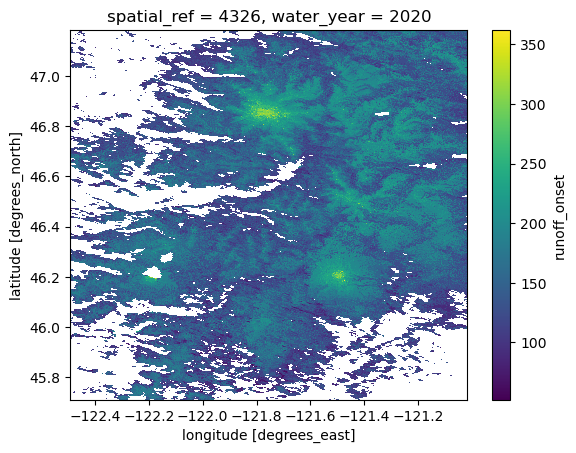

In [12]:
import xarray as xr

session = repo.readonly_session(tag=tag)
ds = xr.open_zarr(session.store, zarr_format=3, consolidated=False, decode_coords='all', chunks='auto')

region = store.tile_region_slices(config, 25, 39)
rainier_da = ds['runoff_onset'].sel(water_year=2020).isel(**region).load()
n_valid = int(rainier_da.notnull().sum())
assert n_valid > 0
print(f'tag {tag}, tile (25,39) WY2020: {n_valid:,} valid px, '
      f'median DOWY {float(rainier_da.median()):.0f}')

rainier_da.plot.imshow(cmap='viridis',)

Ledger parity — the same walks `2_check_tile_status.ipynb` does, against the cleaned repo:

In [13]:
tiles_gdf = status.get_tile_status_gdf(config, repo=repo)
commits_after = status.get_commit_records(repo)

assert len(commits_after) == len(commits_df), 'pipeline commits went missing'
print(tiles_gdf.tile_status.value_counts().to_string())
assert (tiles_gdf.tile_status == 'complete').all()
print('commit history intact -- status derivation unaffected by the cleanup')

tile_status
complete    4392
commit history intact -- status derivation unaffected by the cleanup
